<a href="https://colab.research.google.com/github/Komali-devireddy/Dijkstra-s-algorithm-to-all-the-cities-in-India-and-their-Road-distances/blob/main/Dijkstra%E2%80%99s_Algorithm_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Dijkstra’s Algorithm


##Import libraries

In [ ]:
import pandas as pd
import heapq
import matplotlib.pyplot as plt
import requests
from io import StringIO

#Automatically download the dataset

In [ ]:
# Open-source Indian cities road-distance dataset
url = "https://gist.githubusercontent.com/kshipra-jadav/4697f52b61dc246e37441ca88c59cfa5/raw/indian-cities-dataset.csv"

response = requests.get(url)

if response.status_code == 200:
    df = pd.read_csv(StringIO(response.text))
    print("Dataset downloaded successfully!")
else:
    print("Download failed. Status code:", response.status_code)

print("\nDataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 10 rows:")
display(df.head(10))

Dataset downloaded successfully!

Dataset shape: (85, 3)

Columns:
['Origin', 'Destination', 'Distance']

First 10 rows:


,Origin,Destination,Distance
0,Agra,Delhi,240
1,Agra,Lucknow,334
2,Agra,Kanpur,277
3,Ahmedabad,Mumbai,526
4,Ahmedabad,Pune,663
5,Ahmedabad,Jaipur,660
6,Ahmedabad,Udaipur,258
7,Bengaluru,Pune,839
8,Bengaluru,Hyderabad,576
9,Bengaluru,Chennai,346


#Clean the dataset

In [ ]:
# Rename columns to make programming easier

df = df.rename(columns={
    "Origin": "source",
    "Destination": "target",
    "Distance": "distance"
})

# Remove missing values
df = df.dropna()

# Convert distance to numeric
df["distance"] = pd.to_numeric(
    df["distance"],
    errors="coerce"
)

df = df.dropna()

print("Cleaned dataset:")
display(df.head())

print("\nNumber of road connections:", len(df))

Cleaned dataset:


,source,target,distance
0,Agra,Delhi,240
1,Agra,Lucknow,334
2,Agra,Kanpur,277
3,Ahmedabad,Mumbai,526
4,Ahmedabad,Pune,663



Number of road connections: 85


#Create the weighted graph

In [ ]:
graph = {}

for _, row in df.iterrows():

    source = row["source"]
    target = row["target"]
    distance = float(row["distance"])

    if source not in graph:
        graph[source] = []

    if target not in graph:
        graph[target] = []

    # Bidirectional road
    graph[source].append((target, distance))
    graph[target].append((source, distance))

print("Number of cities:", len(graph))

print("\nCities:")
print(sorted(graph.keys()))

Number of cities: 20

Cities:
['Agra', 'Ahmedabad', 'Bengaluru', 'Bhubaneswar', 'Chennai', 'Delhi', 'Goa', 'Hyderabad', 'Jaipur', 'Kanpur', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai', 'Patna', 'Pune', 'Thiruvananthapuram', 'Udaipur', 'Varanasi', 'Vishakhapatnam']


#Implement Dijkstra's Algorithm

In [ ]:
def dijkstra(graph, source):

    # Step 1: Set all distances to infinity
    distances = {
        city: float("inf")
        for city in graph
    }

    # Store previous city for path reconstruction
    previous = {
        city: None
        for city in graph
    }

    # Step 2: Distance from source to itself = 0
    distances[source] = 0

    # Step 3: Priority queue
    priority_queue = [(0, source)]

    while priority_queue:

        # Step 4: Select city with minimum distance
        current_distance, current_city = heapq.heappop(
            priority_queue
        )

        # Ignore outdated values
        if current_distance > distances[current_city]:
            continue

        # Step 5: Check neighbouring cities
        for neighbour, road_distance in graph[current_city]:

            # Step 6: Calculate new distance
            new_distance = (
                current_distance + road_distance
            )

            # Step 7: Relaxation
            if new_distance < distances[neighbour]:

                distances[neighbour] = new_distance

                previous[neighbour] = current_city

                heapq.heappush(
                    priority_queue,
                    (new_distance, neighbour)
                )

    return distances, previous

#Find shortest distance from Delhi to ALL cities

In [ ]:
source = "Delhi"

distances, previous = dijkstra(
    graph,
    source
)

print("Shortest road distances from Delhi")
print("=" * 50)

for city, distance in sorted(
    distances.items(),
    key=lambda x: x[1]
):

    print(
        f"{city:20} : {distance:.0f} km"
    )

Shortest road distances from Delhi
Delhi                : 0 km
Agra                 : 240 km
Jaipur               : 307 km
Kanpur               : 517 km
Lucknow              : 548 km
Udaipur              : 688 km
Varanasi             : 845 km
Ahmedabad            : 945 km
Patna                : 1101 km
Mumbai               : 1452 km
Pune                 : 1498 km
Kolkata              : 1525 km
Hyderabad            : 1582 km
Bhubaneswar          : 1932 km
Goa                  : 1940 km
Bengaluru            : 2158 km
Vishakhapatnam       : 2200 km
Chennai              : 2208 km
Kochi                : 2694 km
Thiruvananthapuram   : 2900 km


#Reconstruct the shortest path

In [ ]:
def get_path(previous, source, destination):

    path = []

    current = destination

    while current is not None:

        path.append(current)

        current = previous[current]

    path.reverse()

    if path[0] != source:
        return []

    return path

#Find a particular route

In [ ]:
source = "Delhi"
destination = "Mumbai"

distances, previous = dijkstra(
    graph,
    source
)

path = get_path(
    previous,
    source,
    destination
)

print("Source:", source)
print("Destination:", destination)

print("\nShortest Path:")
print(" → ".join(path))

print(
    "\nShortest Road Distance:",
    distances[destination],
    "km"
)

Source: Delhi
Destination: Mumbai

Shortest Path:
Delhi → Mumbai

Shortest Road Distance: 1452.0 km


#Create a complete result table

In [ ]:
results = []

for city in sorted(distances):

    path = get_path(
        previous,
        source,
        city
    )

    results.append({
        "Source": source,
        "Destination": city,
        "Shortest Distance (km)": distances[city],
        "Shortest Path": " → ".join(path)
    })

results_df = pd.DataFrame(results)

display(results_df)

,Source,Destination,Shortest Distance (km),Shortest Path
0,Delhi,Agra,240.0,Delhi → Agra
1,Delhi,Ahmedabad,945.0,Delhi → Udaipur → Ahmedabad
2,Delhi,Bengaluru,2158.0,Delhi → Hyderabad → Bengaluru
3,Delhi,Bhubaneswar,1932.0,Delhi → Agra → Kanpur → Varanasi → Patna → Bhu...
4,Delhi,Chennai,2208.0,Delhi → Chennai
5,Delhi,Delhi,0.0,Delhi
6,Delhi,Goa,1940.0,Delhi → Jaipur → Pune → Goa
7,Delhi,Hyderabad,1582.0,Delhi → Hyderabad
8,Delhi,Jaipur,307.0,Delhi → Jaipur
9,Delhi,Kanpur,517.0,Delhi → Agra → Kanpur


#Plot shortest distances

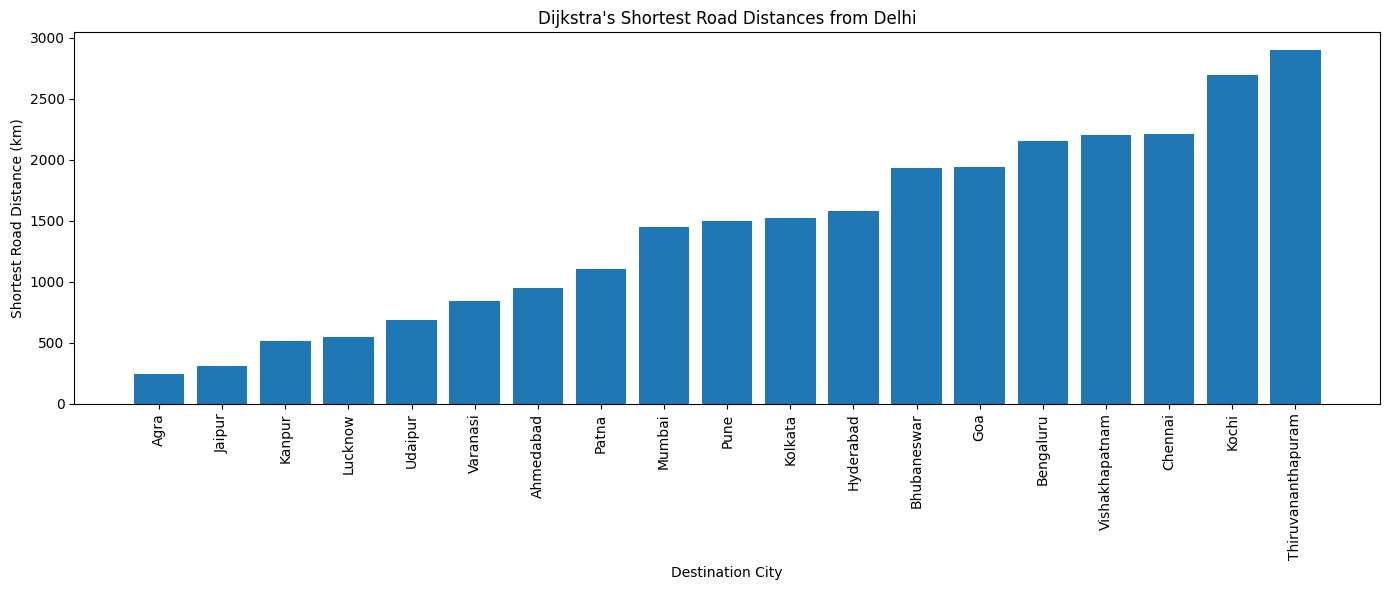

In [ ]:
plot_df = results_df[
    results_df["Destination"] != source
].sort_values(
    "Shortest Distance (km)"
)

plt.figure(figsize=(14, 6))

plt.bar(
    plot_df["Destination"],
    plot_df["Shortest Distance (km)"]
)

plt.xlabel("Destination City")
plt.ylabel("Shortest Road Distance (km)")
plt.title(
    "Dijkstra's Shortest Road Distances from " + source
)

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

#Make it interactive

In [ ]:
print("Available cities:")
print(", ".join(sorted(graph.keys())))

source = input(
    "\nEnter source city: "
).strip()

if source not in graph:

    print("\nCity not found!")

else:

    distances, previous = dijkstra(
        graph,
        source
    )

    print(
        "\nShortest distances from",
        source
    )

    print("=" * 50)

    for city, distance in sorted(
        distances.items(),
        key=lambda x: x[1]
    ):

        print(
            f"{city:20} : {distance:.0f} km"
        )

Available cities:
Agra, Ahmedabad, Bengaluru, Bhubaneswar, Chennai, Delhi, Goa, Hyderabad, Jaipur, Kanpur, Kochi, Kolkata, Lucknow, Mumbai, Patna, Pune, Thiruvananthapuram, Udaipur, Varanasi, Vishakhapatnam

Enter source city: Delhi

Shortest distances from Delhi
Delhi                : 0 km
Agra                 : 240 km
Jaipur               : 307 km
Kanpur               : 517 km
Lucknow              : 548 km
Udaipur              : 688 km
Varanasi             : 845 km
Ahmedabad            : 945 km
Patna                : 1101 km
Mumbai               : 1452 km
Pune                 : 1498 km
Kolkata              : 1525 km
Hyderabad            : 1582 km
Bhubaneswar          : 1932 km
Goa                  : 1940 km
Bengaluru            : 2158 km
Vishakhapatnam       : 2200 km
Chennai              : 2208 km
Kochi                : 2694 km
Thiruvananthapuram   : 2900 km


#Source → Destination shortest path

In [ ]:
source = input(
    "Enter source city: "
).strip()

destination = input(
    "Enter destination city: "
).strip()

if source not in graph:

    print("Source city not found.")

elif destination not in graph:

    print("Destination city not found.")

else:

    distances, previous = dijkstra(
        graph,
        source
    )

    path = get_path(
        previous,
        source,
        destination
    )

    print("\nShortest Path:")
    print(" → ".join(path))

    print(
        "\nMinimum Road Distance:",
        distances[destination],
        "km"
    )

Enter source city: Delhi
Enter destination city: Hyderabad

Shortest Path:
Delhi → Hyderabad

Minimum Road Distance: 1582.0 km
